 **Dataset**
--
    EDA
    
### **Data Description**
This dataset is designed for predicting energy consumption based on various building features and environmental factors. 

### **Features**
    Age: Age of primary beneficiary
    Square Footage: Numeric feature representing the total square footage of the building.
    Number of Occupants: Numeric feature indicating the number of people occupying the building.
    Appliances used: Numeric feature representing the number of appliances used in the building. 
    Average Temperature: Numeric feature representing the average temperature of the building or climate area (in Celsius).
    Day of the week: Categorical feature representing whether the data point corresponds to a weekday or weekend.
    Energy Consumption: Numeric target variable representing the energy consumption of the building in kWh (kilowatt-hours). This is the value the model is tasked with predicting.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import warnings 
warnings.filterwarnings('ignore')

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/energy-consumption-dataset-linear-regression/train_energy_data.csv
/kaggle/input/energy-consumption-dataset-linear-regression/test_energy_data.csv


## **Import Libraries**

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# **EDA**

## **Data Exploration**
    During this step we can explore the shape of the data we are working with. It's usual to check and deal with the number of columns and rows, missing values, outliers and other inconsistencies that might appear.
--

In [3]:
dataframe = pd.read_csv('/kaggle/input/energy-consumption-dataset-linear-regression/train_energy_data.csv')
dataframe

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17
...,...,...,...,...,...,...,...
995,Residential,14419,68,44,23.95,Weekend,3661.21
996,Industrial,12194,7,22,14.67,Weekend,3546.34
997,Commercial,39562,88,20,32.18,Weekday,5147.21
998,Residential,8348,67,37,16.48,Weekend,3244.98


In [4]:
dataframe.dtypes

Building Type           object
Square Footage           int64
Number of Occupants      int64
Appliances Used          int64
Average Temperature    float64
Day of Week             object
Energy Consumption     float64
dtype: object

In [5]:
dataframe['Energy Consumption'] = dataframe['Energy Consumption'].astype(int)

Checking missing values

In [6]:
dataframe.isnull().mean() # Checking null in each column

Building Type          0.0
Square Footage         0.0
Number of Occupants    0.0
Appliances Used        0.0
Average Temperature    0.0
Day of Week            0.0
Energy Consumption     0.0
dtype: float64

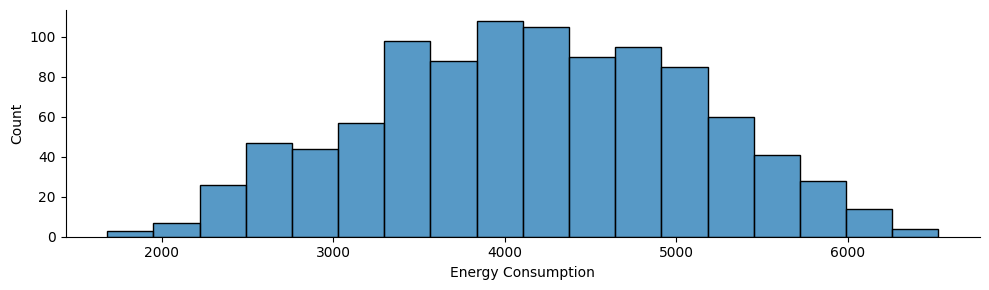

In [7]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))

sns.histplot(data=dataframe, x= 'Energy Consumption')

sns.despine(left=False, right=True, top=True, bottom=False)
plt.tight_layout()

Checking Normality

In [8]:
from scipy.stats import shapiro
import scipy.stats as stats

# Perform Shapiro-Wilk test
stat, p_value = shapiro(dataframe['Energy Consumption'])

print(f"Shapiro-Wilk Statistic (W): {stat:.4f}")
print(f"p-value: {p_value:.4f}")

# Interpret the result
alpha = 0.05
if p_value < alpha:
    print("Data is NOT normally distributed (reject H₀)")
else:
    print("Data is normally distributed (fail to reject H₀)")

Shapiro-Wilk Statistic (W): 0.9935
p-value: 0.0002
Data is NOT normally distributed (reject H₀)


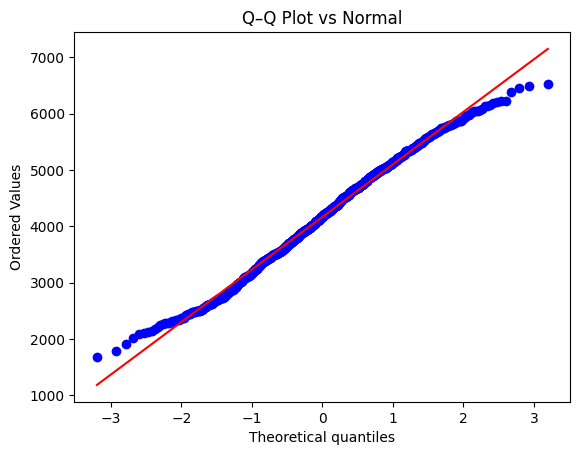

AVG Energy Consumption: 4165.76
Energy Consumption STD: 933.32


In [9]:
stats.probplot(dataframe['Energy Consumption'], dist="norm", plot=plt)
plt.title("Q–Q Plot vs Normal")
plt.show()

print(f"AVG Energy Consumption: {dataframe['Energy Consumption'].mean():.2f}")
print(f"Energy Consumption STD: {dataframe['Energy Consumption'].std():.2f}")


Applying another test to verify again

In [10]:
from scipy.stats import anderson

result = anderson(dataframe['Energy Consumption'], dist='norm')

stat = result.statistic
alpha = result.critical_values[2]  # 5% level

if stat < alpha:
    print("Data is normally distributed (fail to reject H₀)")
else:
    print("Data is NOT normally distributed (reject H₀)")

Data is NOT normally distributed (reject H₀)


## **Statistical Analysis**
    This step seeks to understand the interaction and correlation among the features. Here it's possible to check multicolinearity, plot visulizations and highlight key points.
--

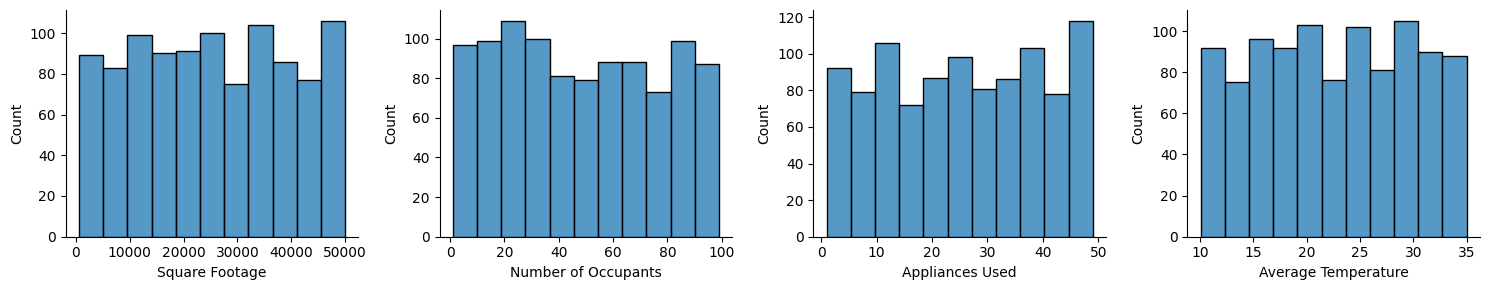

In [11]:
# Checking the distribution of the quantitative columns

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(15, 3))

ax[0] = sns.histplot(data=dataframe, x= 'Square Footage', ax=ax[0])
ax[1] = sns.histplot(data=dataframe, x= 'Number of Occupants', ax=ax[1])
ax[2] = sns.histplot(data=dataframe, x= 'Appliances Used', ax=ax[2])
ax[3] = sns.histplot(data=dataframe, x= 'Average Temperature', ax=ax[3])

sns.despine(left=False, right=True, top=True, bottom=False)
plt.tight_layout()

#### **Residential Buildings**

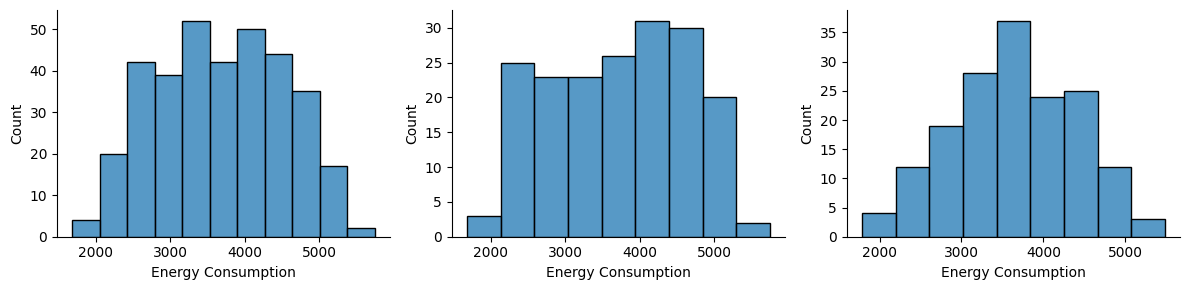

In [12]:
residential_consumption_weekday = dataframe[(dataframe["Building Type"] == "Residential") & (dataframe["Day of Week"] == "Weekday")]
residential_consumption_weekend = dataframe[(dataframe["Building Type"] == "Residential") & (dataframe["Day of Week"] == "Weekend")]
residential_consumption = dataframe[dataframe["Building Type"] == "Residential"]

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 3))

ax[0] = sns.histplot(data=residential_consumption, x= 'Energy Consumption', ax = ax[0])
ax[1] = sns.histplot(data=residential_consumption_weekday, x= 'Energy Consumption', ax=ax[1])
ax[2] = sns.histplot(data=residential_consumption_weekend, x= 'Energy Consumption', ax=ax[2])

sns.despine(left=False, right=True, top=True, bottom=False)
plt.tight_layout()

##### **ChebyShev's Proportion**

In [13]:
residential_mean = residential_consumption['Energy Consumption'].mean().astype(int)
residential_std = residential_consumption['Energy Consumption'].std()

k = 2  #STDs from the mean

chebyshev_bound = 1-1/(k**2)

lower_bound = residential_mean - residential_std * k
upper_bound = residential_mean + residential_std * k

print(f'At least {chebyshev_bound*100:.0f}% of the energy consumption in Residential buildings is expected to fall between {lower_bound:.2f}kWh and {upper_bound:.2f}kWh')

At least 75% of the energy consumption in Residential buildings is expected to fall between 1985.77kWh and 5376.23kWh


#### **Commercial Buildings**

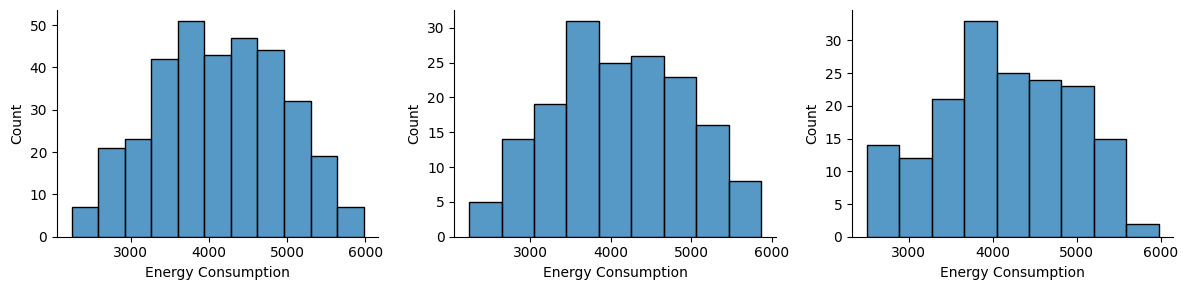

In [14]:
commercial_consumption_weekday = dataframe[(dataframe["Building Type"] == "Commercial") & (dataframe["Day of Week"] == "Weekday")]
commercial_consumption_weekend = dataframe[(dataframe["Building Type"] == "Commercial") & (dataframe["Day of Week"] == "Weekend")]
commercial_consumption = dataframe[dataframe["Building Type"] == "Commercial"]

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 3))

ax[0] = sns.histplot(data=commercial_consumption, x= 'Energy Consumption', ax = ax[0])
ax[1] = sns.histplot(data=commercial_consumption_weekday, x= 'Energy Consumption', ax=ax[1])
ax[2] = sns.histplot(data=commercial_consumption_weekend, x= 'Energy Consumption', ax=ax[2])

sns.despine(left=False, right=True, top=True, bottom=False)
plt.tight_layout()

##### **ChebyShev's Proportion**

In [15]:
commercial_mean = commercial_consumption['Energy Consumption'].mean().astype(int)
commercial_std = commercial_consumption['Energy Consumption'].std()

k = 2  #STDs from the mean

chebyshev_bound = 1-1/(k**2)

lower_bound = commercial_mean - commercial_std * k
upper_bound = commercial_mean + commercial_std * k

print(f'At least {chebyshev_bound*100:.0f}% of the energy consumption in Commercial buildings is expected to fall between {lower_bound:.2f}kWh and {upper_bound:.2f}kWh')

At least 75% of the energy consumption in Commercial buildings is expected to fall between 2509.28kWh and 5748.72kWh


#### **Industrial Buildings**

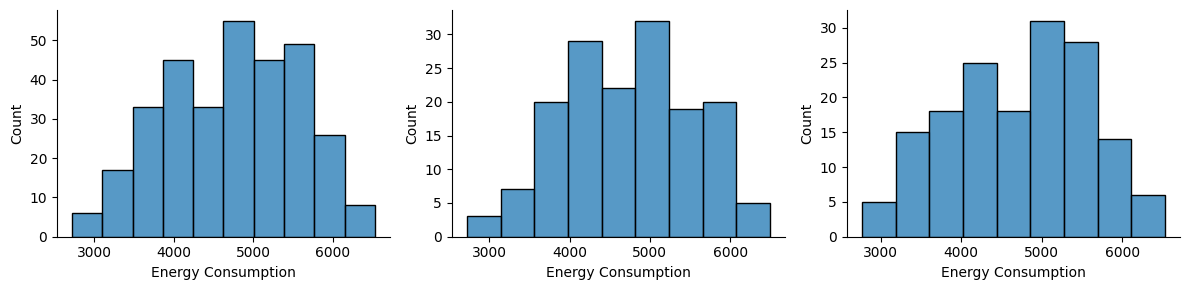

In [16]:
Industrial_consumption_weekday = dataframe[(dataframe["Building Type"] == "Industrial") & (dataframe["Day of Week"] == "Weekday")]
Industrial_consumption_weekend = dataframe[(dataframe["Building Type"] == "Industrial") & (dataframe["Day of Week"] == "Weekend")]
Industrial_consumption = dataframe[dataframe["Building Type"] == "Industrial"]

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 3))

ax[0] = sns.histplot(data=Industrial_consumption, x= 'Energy Consumption', ax = ax[0])
ax[1] = sns.histplot(data=Industrial_consumption_weekday, x= 'Energy Consumption', ax=ax[1])
ax[2] = sns.histplot(data=Industrial_consumption_weekend, x= 'Energy Consumption', ax=ax[2])

sns.despine(left=False, right=True, top=True, bottom=False)
plt.tight_layout()

##### **ChebyShev's Proportion**

In [17]:
industrial_mean = Industrial_consumption['Energy Consumption'].mean().astype(int)
industrial_std = Industrial_consumption['Energy Consumption'].std()

k = 2  #STDs from the mean

chebyshev_bound = 1-1/(k**2)

lower_bound = industrial_mean - industrial_std * k
upper_bound = industrial_mean + industrial_std * k

print(f'At least {chebyshev_bound*100:.0f}% of the energy consumption in Industrial buildings is expected to fall between {lower_bound:.2f}kWh and {upper_bound:.2f}kWh')

At least 75% of the energy consumption in Industrial buildings is expected to fall between 3075.21kWh and 6392.79kWh


"Probability" Calculations

In [18]:
from scipy.stats import norm
import numpy as np

Residential x Commercial - "Probability" of Residential consumption taking the AVG consumption of Commercial buildings

In [19]:
pdf = norm.pdf(commercial_mean, loc=residential_mean, scale=residential_std)
cdf = norm.cdf(commercial_mean, loc=residential_mean, scale=residential_std)

print(f'Assuming the distribution of the Residential Consumption in this dataset, '
    f'the average consumption of a Commercial Building ({commercial_mean:.2f}kWh) lies in a low-density region of the residential distribution {pdf*100:.2f}%, indicating it is relatively uncommon. '
    f'Additionally, {cdf*100:.2f}% of the observations of residential consumption are below this level.')

Assuming the distribution of the Residential Consumption in this dataset, the average consumption of a Commercial Building (4129.00kWh) lies in a low-density region of the residential distribution 0.04%, indicating it is relatively uncommon. Additionally, 70.14% of the observations of residential consumption are below this level.


Residential x Industrial - "Probability" of Residential consumption taking the AVG consumption of Industrial buildings

In [20]:
pdf = norm.pdf(industrial_mean, loc=residential_mean, scale=residential_std)
cdf = norm.cdf(industrial_mean, loc=residential_mean, scale=residential_std)

print(f'Assuming the distribution of the Residential Consumption in this dataset, '
    f'the average consumption of a Industrial Building ({industrial_mean:.2f}kWh) lies in a low-density region of the residential distribution {pdf*100:.2f}%, indicating it is relatively uncommon. '
    f'Additionally, {cdf*100:.2f}% of the observations of residential consumption are below this level.')

Assuming the distribution of the Residential Consumption in this dataset, the average consumption of a Industrial Building (4734.00kWh) lies in a low-density region of the residential distribution 0.02%, indicating it is relatively uncommon. Additionally, 89.29% of the observations of residential consumption are below this level.


Commercial x Industrial - "Probability" of Commercial consumption taking the AVG consumption of Industrial buildings

In [21]:
pdf = norm.pdf(industrial_mean, loc=commercial_mean, scale=commercial_std)
cdf = norm.cdf(industrial_mean, loc=commercial_mean, scale=commercial_std)

print(f'Assuming the distribution of the Commercial Consumption in this dataset, '
    f'the average consumption of a Industrial Building ({industrial_mean:.2f}kWh) lies in a low-density region of the commercial distribution {pdf*100:.2f}%, indicating it is relatively uncommon. '
    f'Additionally, {cdf*100:.2f}% of the observations of commercial consumption are below this level.')

Assuming the distribution of the Commercial Consumption in this dataset, the average consumption of a Industrial Building (4734.00kWh) lies in a low-density region of the commercial distribution 0.04%, indicating it is relatively uncommon. Additionally, 77.25% of the observations of commercial consumption are below this level.


## **Insights**
--

### **Statistics**:
* The data doesn't follow a Normal Distribution but it's close.
* The dataset shows that Industrial buildings consumption is usually higher than Commercial and Residential buildings.
* The Residential consumption on Weekdays resembles a uniform distribution

# **Thank You for taking the time to view this Notebook**!
​ 
If you found this analysis useful and have any feedback or suggestion, don't hesitate to contact me! We are here to learn!